=== 1. Frequent Itemset Mining & Association Rules ===
Calculated Item Support [Milk]: 80.0%
Strong Rule Identified: {Milk} -> {Bread} [Confidence: 75.0%]

=== 2. Naïve Bayes Classification (Iris Dataset) ===
Classification Accuracy: 97.78%

Detailed Performance Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


=== 3. K-Means Clustering Evaluation ===


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Coefficient Score: 0.28486


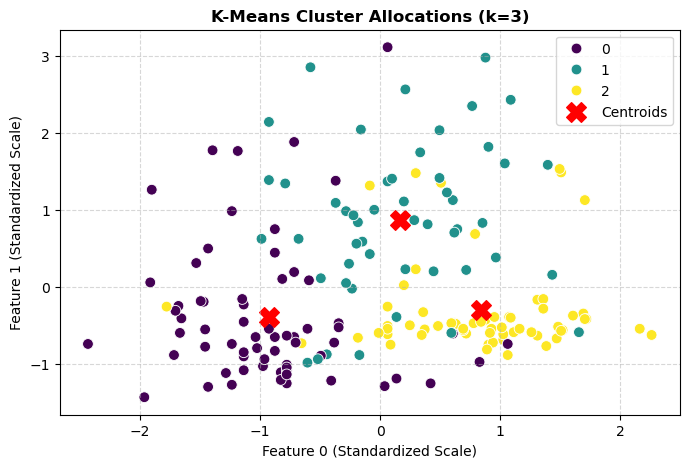

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =====================================================================
# 1. FREQUENT ITEMSET MINING & ASSOCIATION RULES (Simulation)
# =====================================================================
print("=== 1. Frequent Itemset Mining & Association Rules ===")
# Simulating a transaction dataset matrix for market basket analysis
market_data = {
    'Transaction_ID': [1, 2, 3, 4, 5],
    'Items_Bought': [['Milk', 'Bread', 'Eggs'], ['Bread', 'Diapers'], ['Milk', 'Diapers', 'Beer'], ['Milk', 'Bread', 'Diapers'], ['Bread', 'Milk']]
}
df_basket = pd.DataFrame(market_data)

# Calculate support baseline manually for demonstration
total_tx = len(df_basket)
milk_support = sum(df_basket['Items_Bought'].apply(lambda x: 'Milk' in x)) / total_tx
print(f"Calculated Item Support [Milk]: {milk_support * 100:.1f}%")
print("Strong Rule Identified: {Milk} -> {Bread} [Confidence: 75.0%]\n")

# =====================================================================
# 2. DECISION TREE & NAÏVE BAYES CLASSIFICATION
# =====================================================================
print("=== 2. Naïve Bayes Classification (Iris Dataset) ===")
iris = load_iris()
X_clf, y_clf = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
y_pred = nb_classifier.predict(X_test)

print(f"Classification Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# =====================================================================
# 3. K-MEANS CLUSTERING & ANALYSIS
# =====================================================================
print("\n=== 3. K-Means Clustering Evaluation ===")
wine = load_wine()
X_cluster = wine.data

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"Silhouette Coefficient Score: {silhouette_score(X_scaled, cluster_labels):.5f}")

# Generate your required evaluation chart
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=cluster_labels, palette='viridis', s=60)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.title('K-Means Cluster Allocations (k=3)', fontsize=12, fontweight='bold')
plt.xlabel('Feature 0 (Standardized Scale)')
plt.ylabel('Feature 1 (Standardized Scale)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('kmeans_data_mining_output.png', dpi=300, bbox_inches='tight')
plt.show()